In [1]:
import json
import logging
import re
from pathlib import Path
from typing import List, Optional, Tuple

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import scienceplots  # noqa: F401

plt.style.use("science")


In [2]:
logging.basicConfig(
    level=logging.INFO,
    format="%(levelname)s: %(message)s",
)

_ALPHA_RE = re.compile(r"^alpha_(?P<val>[-+]?(\d+(\.\d*)?|\.\d+)([eE][-+]?\d+)?)$")


def dotted_get(d: dict, dotted_key: str):
    cur = d
    for part in dotted_key.split("."):
        if isinstance(cur, dict) and part in cur:
            cur = cur[part]
        else:
            return None
    return cur


def find_alpha_value(dir_name: str) -> Optional[float]:
    m = _ALPHA_RE.match(dir_name)
    if not m:
        return None
    try:
        return float(m.group("val"))
    except ValueError:
        return None


def collect_metrics_for_alpha(alpha_dir: Path, metric_key: str, sampling_name: str) -> List[float]:
    values: List[float] = []
    samples_root = alpha_dir / sampling_name
    if not samples_root.exists():
        logging.warning("No '%s' folder in %s", sampling_name, alpha_dir)
        return values

    metric_paths = []
    direct_metrics = samples_root / "metrics.json"
    if direct_metrics.exists():
        metric_paths.append(direct_metrics)
    metric_paths.extend(samples_root.glob("*/metrics.json"))

    seen = set()
    unique_metric_paths = []
    for p in metric_paths:
        rp = p.resolve()
        if rp not in seen:
            seen.add(rp)
            unique_metric_paths.append(p)

    for metrics_path in unique_metric_paths:
        try:
            with metrics_path.open("r") as f:
                metrics = json.load(f)
            val = dotted_get(metrics, metric_key)
            if isinstance(val, (int, float)):
                values.append(float(val))
            else:
                if val is None:
                    logging.debug(
                        "Key '%s' not found in %s (available: %s)",
                        metric_key,
                        metrics_path,
                        list(metrics.keys()),
                    )
                else:
                    logging.warning(
                        "Value for key '%s' in %s is not numeric: %r",
                        metric_key,
                        metrics_path,
                        val,
                    )
        except Exception as e:
            logging.exception("Failed to read metrics from %s: %s", metrics_path, e)
    return values


In [3]:
def gather_per_experiment(exp_dirs: List[Path], metric_key: str, sampling_name: str) -> pd.DataFrame:
    rows = []
    for exp_dir in exp_dirs:
        exp_dir = Path(exp_dir)
        artifacts_dir = exp_dir / "artifacts"
        if not artifacts_dir.exists():
            logging.warning("No artifacts dir in %s", exp_dir)
            continue

        for child in artifacts_dir.iterdir():
            if not child.is_dir():
                continue
            alpha = find_alpha_value(child.name)
            if alpha is None:
                continue
            vals = collect_metrics_for_alpha(child, metric_key, sampling_name)
            n = len(vals)
            if n == 0:
                continue
            mean = float(np.mean(vals))
            std = float(np.std(vals, ddof=1)) if n > 1 else 0.0
            sem = float(std / np.sqrt(n)) if n > 1 else 0.0

            rows.append(
                {
                    "alpha": alpha,
                    "mean": mean,
                    "std": std,
                    "sem": sem,
                    "n": n,
                    "exp_dir": str(exp_dir),
                }
            )

    if not rows:
        logging.warning("No data rows collected. Check paths, keys, and structure.")
        return pd.DataFrame(columns=["alpha", "mean", "std", "sem", "n", "exp_dir"])

    return pd.DataFrame(rows)


In [4]:
def plot_twin_metrics(
    exp_dirs: List[Path],
    metric1_key: str,
    metric2_key: str,
    metric1_label: str = None,
    metric2_label: str = None,
    dataset_name: str = None,
    save_path: str = None,
    fontsize: int = 24,
    labelsize: int = 20,
    figsize: Tuple[float, float] = (5.4, 3.6),
    sampling_name: str = "sample_marginal",
) -> Tuple[plt.Figure, plt.Axes, plt.Axes]:
    mpl.rcParams.update(
        {
            "font.family": "serif",
            "font.size": 16,
            "axes.labelsize": 16,
            "ytick.labelsize": 16,
            "legend.fontsize": 14,
            "axes.spines.top": False,
            "grid.linestyle": ":",
            "grid.alpha": 0.3,
        }
    )

    df1_long = gather_per_experiment(exp_dirs, metric1_key, sampling_name)
    df2_long = gather_per_experiment(exp_dirs, metric2_key, sampling_name)

    if df1_long.empty or df2_long.empty:
        raise ValueError("No data found for one or both metrics. Check experiment paths and metric keys.")

    df1 = (
        df1_long.groupby(["alpha"], as_index=False)
        .agg(mean=("mean", "mean"), std=("mean", "std"), k=("mean", "count"))
    )
    df1["sem"] = (df1["std"] / np.sqrt(df1["k"].clip(lower=1))).fillna(0.0)

    df2 = (
        df2_long.groupby(["alpha"], as_index=False)
        .agg(mean=("mean", "mean"), std=("mean", "std"), k=("mean", "count"))
    )
    df2["sem"] = (df2["std"] / np.sqrt(df2["k"].clip(lower=1))).fillna(0.0)

    alphas1 = set(df1["alpha"].values)
    alphas2 = set(df2["alpha"].values)
    common_alphas = sorted(alphas1.intersection(alphas2))

    if not common_alphas:
        raise ValueError("No common alpha values found between the two metrics")

    df1_plot = df1[df1["alpha"].isin(common_alphas)].sort_values("alpha")
    df2_plot = df2[df2["alpha"].isin(common_alphas)].sort_values("alpha")

    fig, ax1 = plt.subplots(figsize=figsize, dpi=300)
    ax1.set_axisbelow(True)

    c1 = plt.get_cmap("tab10")(0)
    c2 = plt.get_cmap("tab10")(1)

    ax1.errorbar(
        df1_plot["alpha"],
        df1_plot["mean"],
        yerr=df1_plot["sem"],
        marker="o",
        markersize=6,
        linewidth=2.0,
        color=c1,
        capsize=3,
    )

    ax1.set_xlabel(r"$\alpha$", fontsize=fontsize)
    ax1.set_ylabel(metric1_label or metric1_key, color=c1, fontsize=fontsize)
    ax1.tick_params(axis="y", labelcolor=c1, labelsize=labelsize)
    ax1.tick_params(axis="x", labelsize=labelsize)
    ax1.grid(True)

    ax1.xaxis.set_major_locator(mticker.FixedLocator(common_alphas))
    ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:g}"))
    ax1.xaxis.set_minor_locator(mticker.NullLocator())
    ax1.set_xlim(min(common_alphas), max(common_alphas))

    ax2 = ax1.twinx()
    ax2.errorbar(
        df2_plot["alpha"],
        df2_plot["mean"],
        yerr=df2_plot["sem"],
        marker="s",
        markersize=6,
        linewidth=2.0,
        linestyle="--",
        dashes=(5, 3),
        color=c2,
        capsize=3,
    )

    ax2.set_ylabel(metric2_label or metric2_key, color=c2, fontsize=fontsize)
    ax2.tick_params(axis="y", labelcolor=c2, labelsize=labelsize)
    ax2.grid(False)

    if dataset_name:
        fig.suptitle(dataset_name, fontsize=fontsize + 2)

    plt.tight_layout(pad=0.2)

    if save_path:
        plt.savefig(save_path, bbox_inches="tight")
        print(f"Figure saved to: {save_path}")

    plt.show()
    return fig, ax1, ax2


Figure saved to: ../../figures/marginal_interpolation/lung_tumour.pdf


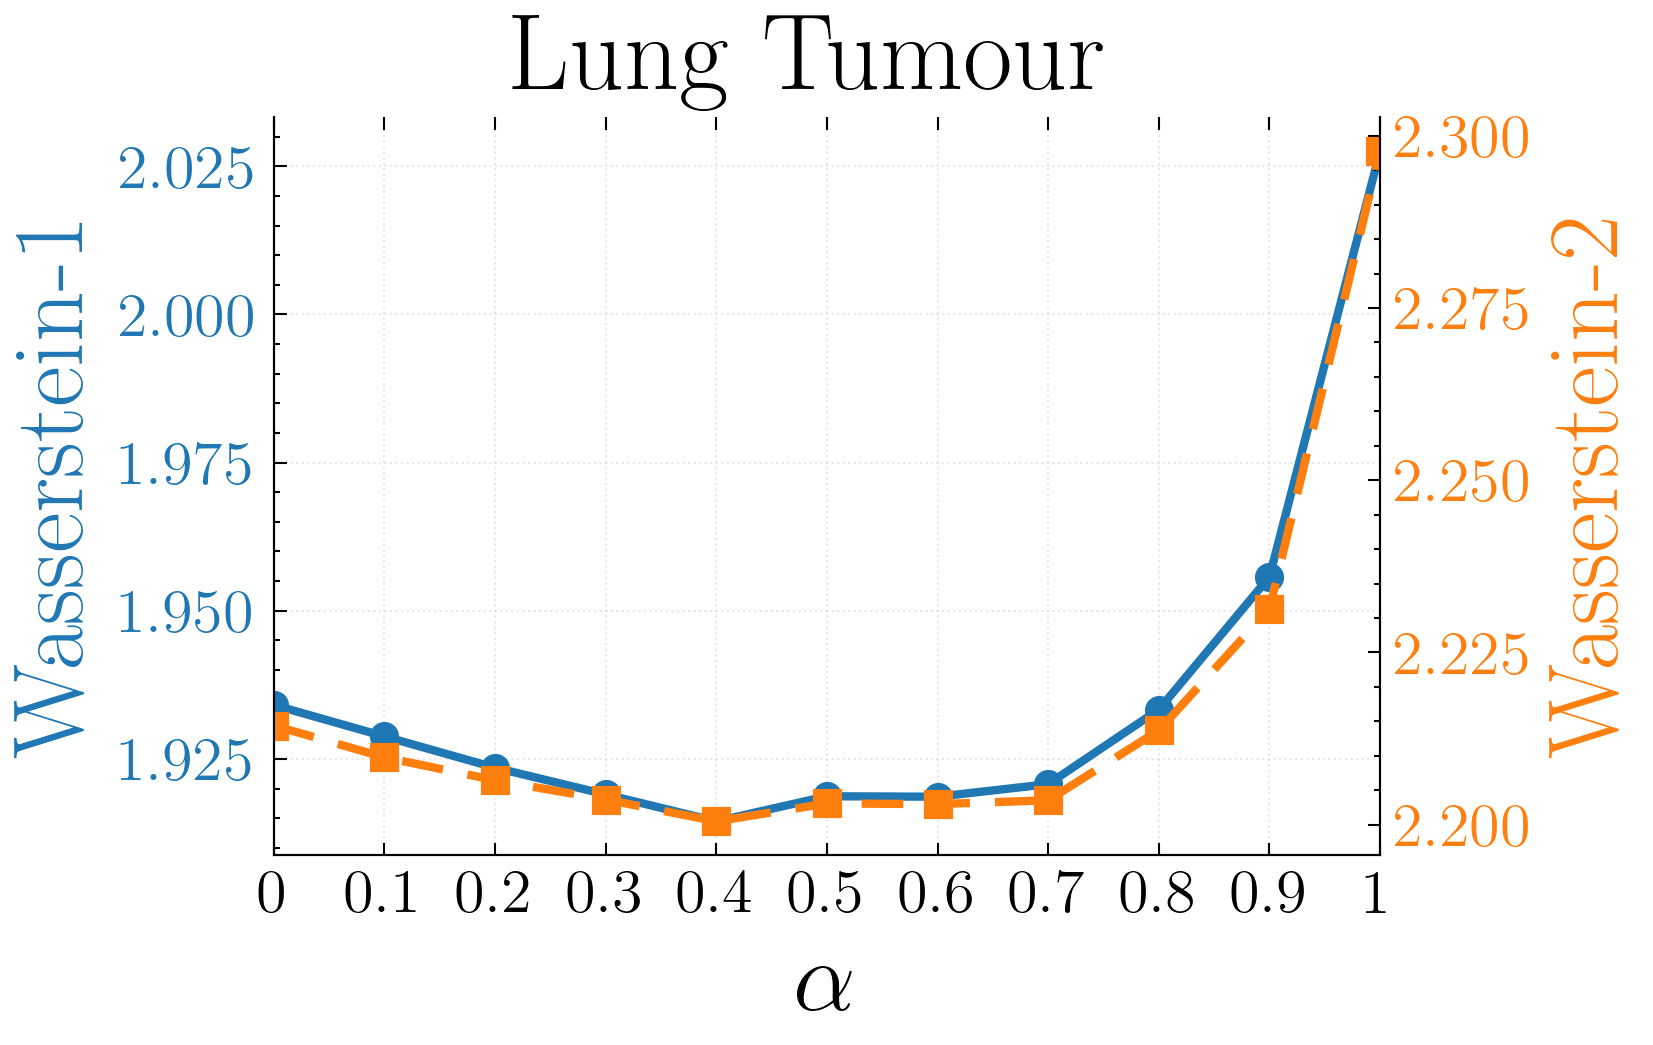

In [5]:
exp_dirs = [Path('/mnt/data/nvth2.data/experiments/cancer/align_sweep/2026-05-18/12-34-33')]

fig, ax1, ax2 = plot_twin_metrics(
    exp_dirs=exp_dirs,
    metric1_key='interpolation.wasserstein_1',
    metric2_key='interpolation.wasserstein_2',
    metric1_label='Wasserstein-1',
    metric2_label='Wasserstein-2',
    dataset_name='Lung Tumour',
    save_path='../../figures/marginal_interpolation/lung_tumour.pdf',
    labelsize=15,
    figsize=(5.4, 3.5),
)

Figure saved to: ../../figures/marginal_interpolation/light.pdf


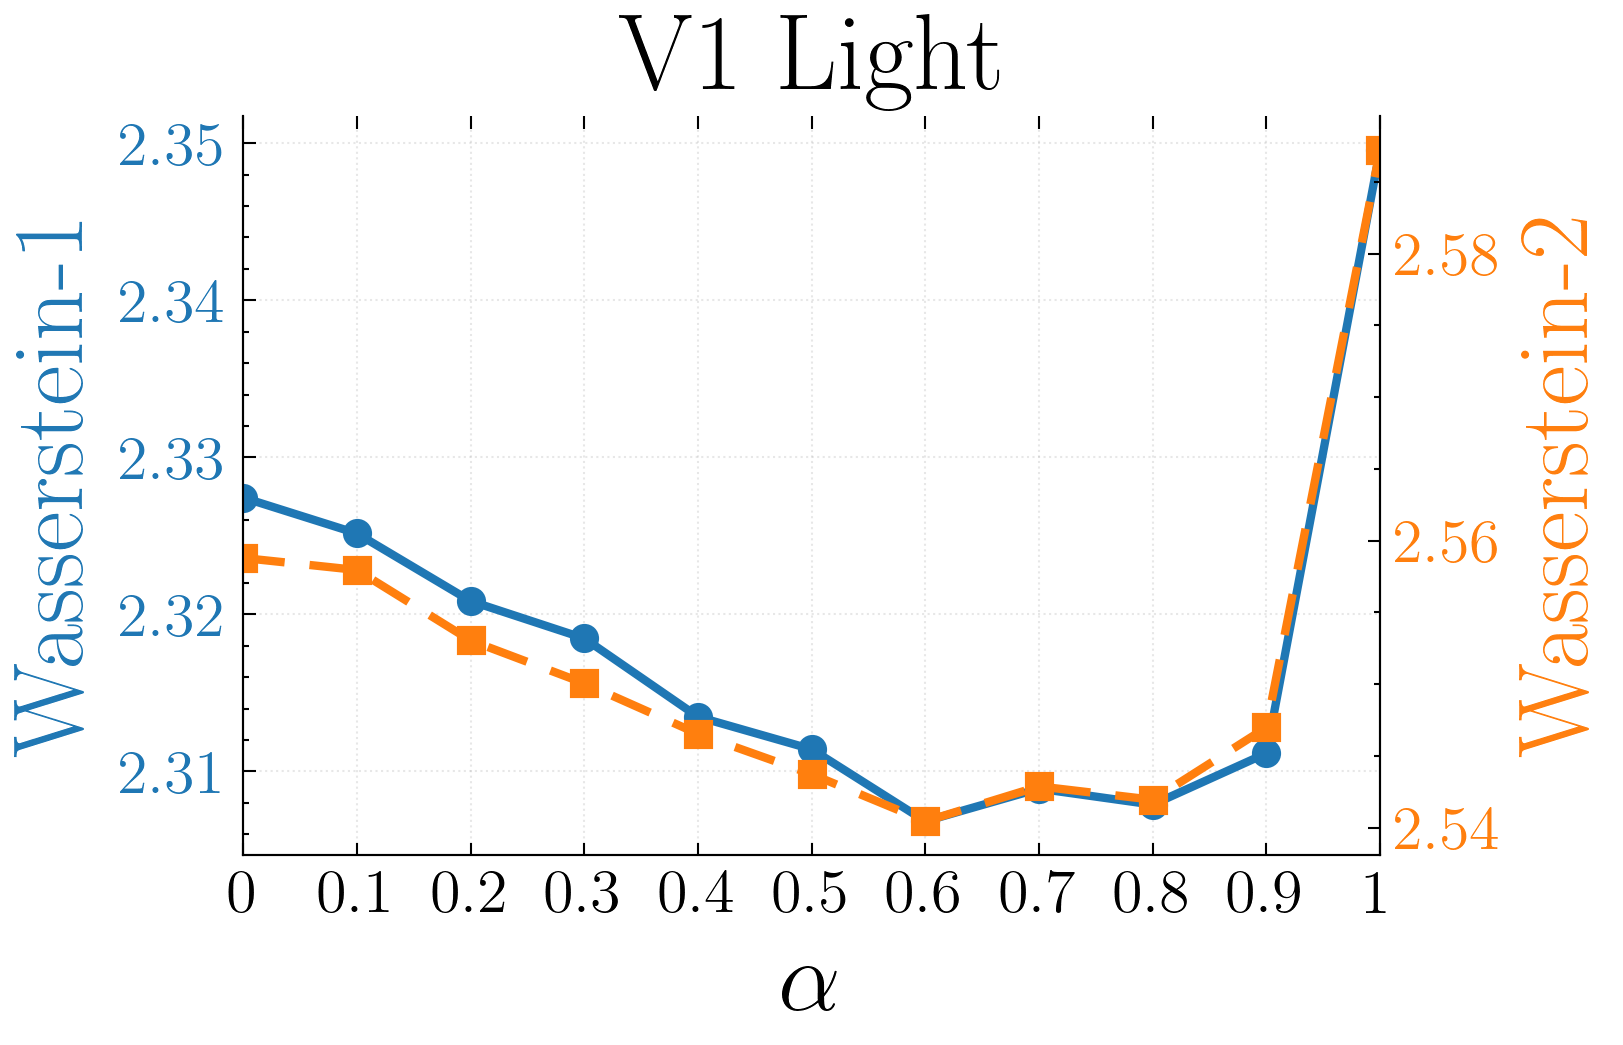

In [6]:
exp_dirs = [Path('/mnt/data/nvth2.data/experiments/light/align_sweep/2026-05-18/12-34-47')]

fig, ax1, ax2 = plot_twin_metrics(
    exp_dirs=exp_dirs,
    metric1_key='interpolation.wasserstein_1',
    metric2_key='interpolation.wasserstein_2',
    metric1_label='Wasserstein-1',
    metric2_label='Wasserstein-2',
    dataset_name='V1 Light',
    save_path='../../figures/marginal_interpolation/light.pdf',
    labelsize=15,
    figsize=(5.4, 3.5),
)


Figure saved to: ../../figures/marginal_interpolation/immune.pdf


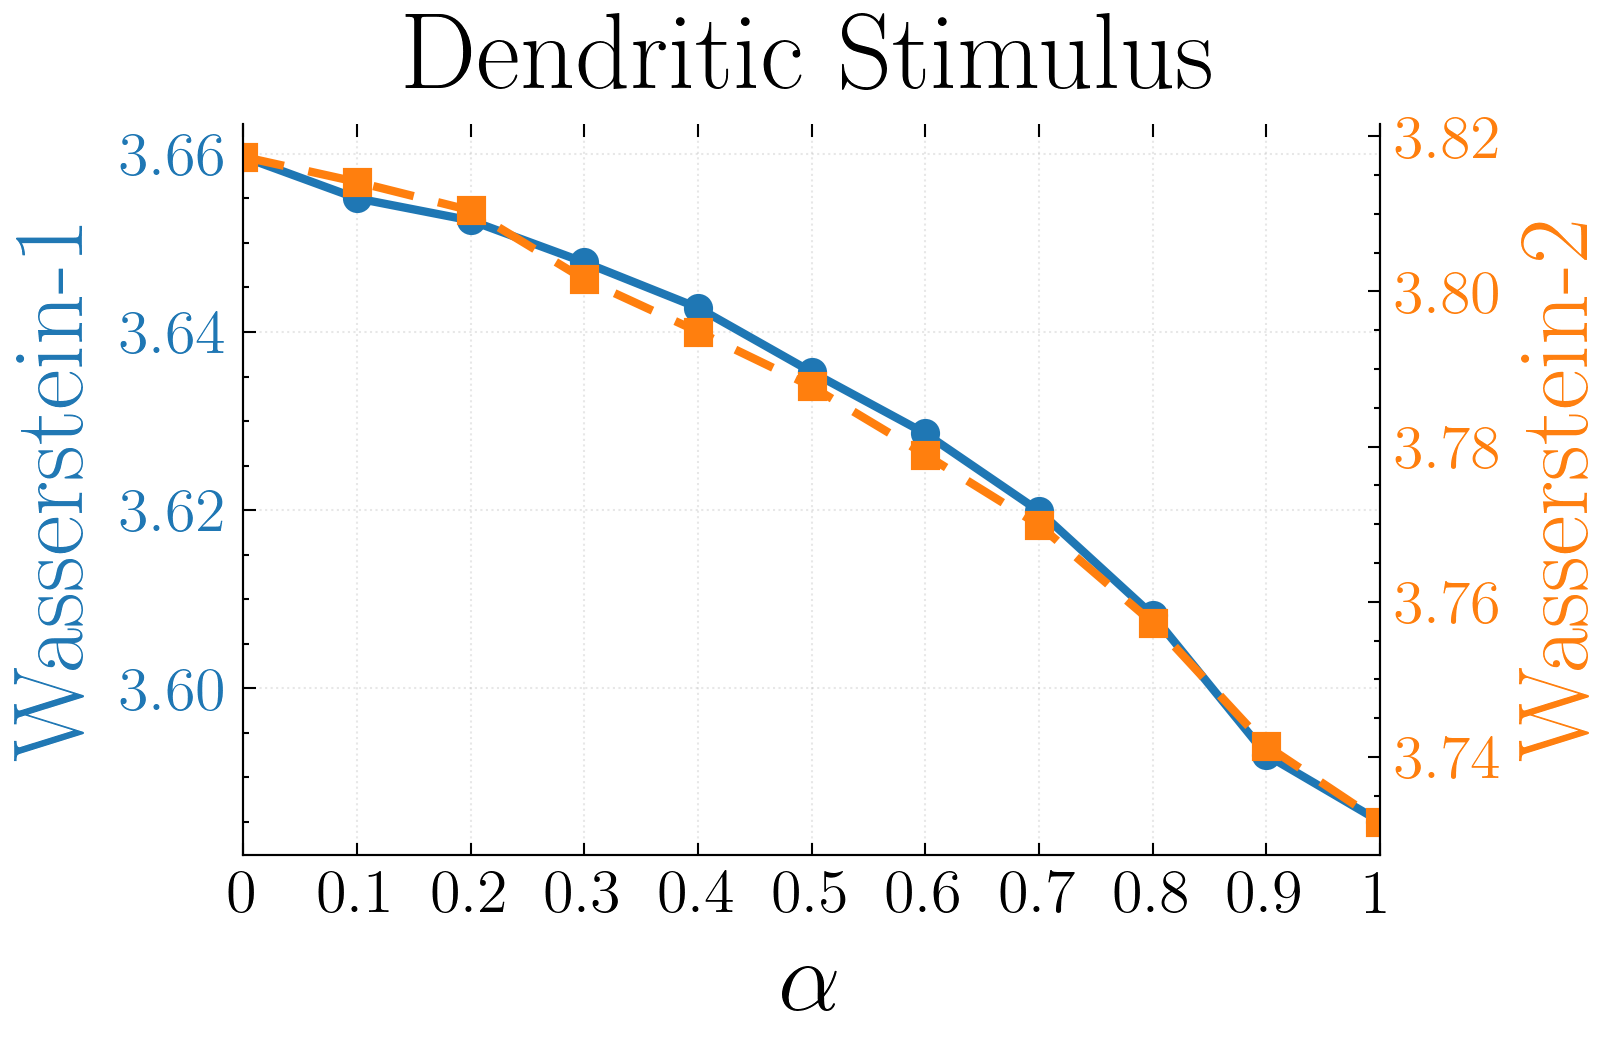

In [7]:
exp_dirs = [Path('/mnt/data/nvth2.data/experiments/immune/align_sweep/2026-05-18/12-29-30')]

fig, ax1, ax2 = plot_twin_metrics(
    exp_dirs=exp_dirs,
    metric1_key='interpolation.wasserstein_1',
    metric2_key='interpolation.wasserstein_2',
    metric1_label='Wasserstein-1',
    metric2_label='Wasserstein-2',
    dataset_name='Dendritic Stimulus',
    save_path='../../figures/marginal_interpolation/immune.pdf',
    labelsize=15,
    figsize=(5.4, 3.5),
)


Figure saved to: ../../figures/marginal_interpolation/embryo.pdf


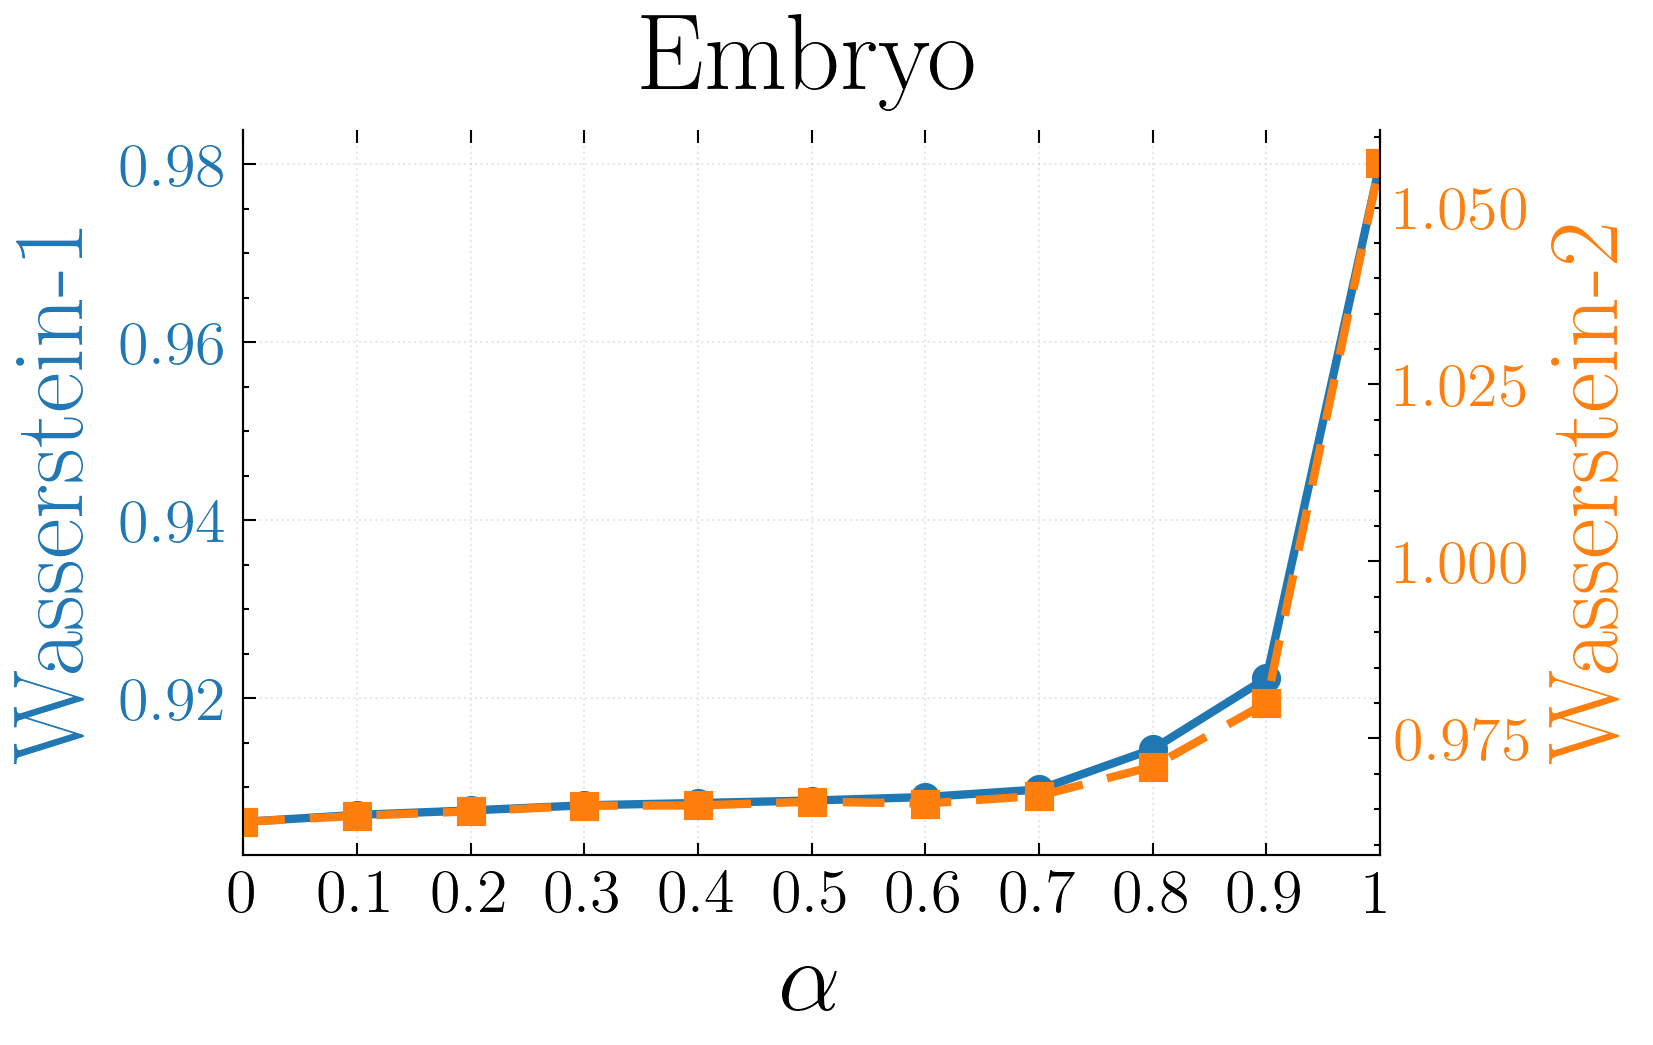

In [8]:
exp_dirs = [Path('/mnt/data/nvth2.data/experiments/embryo/align_sweep/2026-05-18/18-11-15')]

fig, ax1, ax2 = plot_twin_metrics(
    exp_dirs=exp_dirs,
    metric1_key='interpolation.wasserstein_1',
    metric2_key='interpolation.wasserstein_2',
    metric1_label='Wasserstein-1',
    metric2_label='Wasserstein-2',
    dataset_name='Embryo',
    save_path='../../figures/marginal_interpolation/embryo.pdf',
    labelsize=15,
    figsize=(5.4, 3.5),
)
